# Predicting Drug–Target Interactions Using Deep Learning
**CS697-AI687-001 | Group 3 | Spring 2026**  
Naisargi Sharma · Maria Elizathe · Vaibhav Jaiswal

**Before running:** Runtime → Change runtime type → **T4 GPU** → Save  
Then: Runtime → **Run all**

## Step 1 — Install Packages

In [ ]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "rdkit", "--quiet"])
print("All packages ready.")

All packages ready.


## Step 2 — Imports & Setup

In [ ]:
import os, warnings, random, pickle
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image
import matplotlib.cm as mpl_cm

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Draw

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
PyTorch: 2.10.0+cu128
GPU: Tesla T4


## Step 3 — Configuration

In [ ]:
# ── UPDATE THIS PATH after uploading your TSV file ────────────────────────────
DATA_PATH       = '/content/naisargisharma20_gmail.com1419.tsv'
IMAGE_DIR       = '/content/molecular_images'
CHECKPOINT_PATH = '/content/best_resnet18.pth'
os.makedirs(IMAGE_DIR, exist_ok=True)

# Labeling thresholds
ACTIVE_THRESHOLD_nM   = 1000    # IC50 <= 1 uM  → Binder (1)
INACTIVE_THRESHOLD_nM = 10000   # IC50 > 10 uM  → Non-binder (0)

# Image
IMG_SIZE = 224

# Training
BATCH_SIZE    = 32
NUM_EPOCHS    = 50
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-4
DROPOUT_RATE  = 0.3
PATIENCE      = 5

# Splits
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# Random Forest
RF_N_ESTIMATORS       = 100
RF_FINGERPRINT_RADIUS = 2
RF_FINGERPRINT_BITS   = 2048

print("Config ready.")
print(f"  DATA_PATH: {DATA_PATH}")
print(f"  Device:    {DEVICE}")

Config ready.
  DATA_PATH: /content/naisargisharma20_gmail.com1419.tsv
  Device:    cuda


## Step 4 — Load Data

In [ ]:
def load_bindingdb_data(filepath):
    print(f"Loading: {filepath}")
    all_cols = pd.read_csv(filepath, sep='\t', nrows=0).columns.tolist()
    print(f"Total columns: {len(all_cols)}")

    smiles_col  = next((c for c in all_cols if 'smiles'  in c.lower()), None)
    ic50_col    = next((c for c in all_cols if 'ic50'    in c.lower()), None)
    target_col  = next((c for c in all_cols if 'target'  in c.lower() and 'name' in c.lower()), None)
    uniprot_col = next((c for c in all_cols if 'uniprot' in c.lower()), None)

    print(f"SMILES col : {smiles_col}")
    print(f"IC50 col   : {ic50_col}")

    if not smiles_col: raise ValueError(f"No SMILES column. Columns: {all_cols[:10]}")
    if not ic50_col:   raise ValueError(f"No IC50 column. Columns: {all_cols[:10]}")

    cols = [c for c in [smiles_col, ic50_col, target_col, uniprot_col] if c]
    df   = pd.read_csv(filepath, sep='\t', usecols=cols, low_memory=False)

    rename = {}
    if smiles_col:  rename[smiles_col]  = 'smiles'
    if ic50_col:    rename[ic50_col]    = 'ic50_nM'
    if target_col:  rename[target_col]  = 'target_name'
    if uniprot_col: rename[uniprot_col] = 'uniprot_id'
    df = df.rename(columns=rename)

    for col in ['smiles','ic50_nM','target_name','uniprot_id']:
        if col not in df.columns: df[col] = None

    print(f"Shape: {df.shape}")
    display(df.head(3))
    return df

raw_df = load_bindingdb_data(DATA_PATH)

Loading: /content/naisargisharma20_gmail.com1419.tsv
Total columns: 640
SMILES col : Ligand SMILES
IC50 col   : IC50 (nM)
Shape: (28809, 4)


,smiles,target_name,ic50_nM,uniprot_id
0,COc1cc(N(C)CCN(C)C)c(NC(=O)C=C)cc1Nc1nccc(n1)-...,Epidermal growth factor receptor,0.002000,Epidermal growth factor receptor
1,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,Epidermal growth factor receptor,0.003,Epidermal growth factor receptor
2,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,Epidermal growth factor receptor,0.006,Epidermal growth factor receptor


## Step 5 — Preprocessing & Labeling

In [ ]:
def validate_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is not None:
            return Chem.MolToSmiles(mol)
    except Exception:
        pass
    return None

def parse_ic50(value):
    try:
        return float(str(value).strip().replace(',','')
                     .replace('>','').replace('<','').replace('=',''))
    except Exception:
        return None

def preprocess_and_label(df):
    print("=== Preprocessing ===")
    print(f"Step 0 — raw: {len(df)}")
    df = df.dropna(subset=['smiles','ic50_nM']).copy()
    print(f"Step 1 — drop NaN: {len(df)}")
    df['ic50_parsed'] = df['ic50_nM'].apply(parse_ic50)
    df = df.dropna(subset=['ic50_parsed'])
    print(f"Step 2 — IC50 parsed: {len(df)}")
    print("Step 3 — validating SMILES...")
    df['canonical_smiles'] = df['smiles'].apply(validate_smiles)
    df = df.dropna(subset=['canonical_smiles'])
    print(f"Step 3 — valid SMILES: {len(df)}")
    active   = df['ic50_parsed'] <= ACTIVE_THRESHOLD_nM
    inactive = df['ic50_parsed'] >  INACTIVE_THRESHOLD_nM
    df = df[active | inactive].copy()
    df['label'] = active[active | inactive].astype(int)
    print(f"Step 4 — after thresholds: {len(df)}")
    df = df.drop_duplicates(subset=['canonical_smiles']).reset_index(drop=True)
    print(f"Step 5 — after dedup: {len(df)}")
    n_pos = int(df['label'].sum())
    n_neg = len(df) - n_pos
    print(f"Active: {n_pos} ({n_pos/len(df)*100:.1f}%)")
    print(f"Inactive: {n_neg} ({n_neg/len(df)*100:.1f}%)")
    return df[['canonical_smiles','ic50_parsed','label']]

processed_df = preprocess_and_label(raw_df)
display(processed_df.head())

=== Preprocessing ===
Step 0 — raw: 28809
Step 1 — drop NaN: 26539
Step 2 — IC50 parsed: 26539
Step 3 — validating SMILES...


[15:13:54] improperly formatted w block
[15:13:54] improperly formatted w block
[15:13:54] improperly formatted w block
[15:13:54] improperly formatted w block
[15:13:58] Explicit valence for atom # 5 N, 4, is greater than permitted
[15:13:58] Explicit valence for atom # 25 N, 4, is greater than permitted


Step 3 — valid SMILES: 26507
Step 4 — after thresholds: 22491
Step 5 — after dedup: 12870
Active: 10683 (83.0%)
Inactive: 2187 (17.0%)


,canonical_smiles,ic50_parsed,label
0,C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(O...,0.002,1
1,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,0.003,1
2,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,0.006,1
3,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,0.006,1
4,Cc1cc2cc(n1)-c1cnn(C)c1OCCC[C@@H](C1CC1)CN1/C(...,0.007,1


## Step 6 — Dataset Exploration

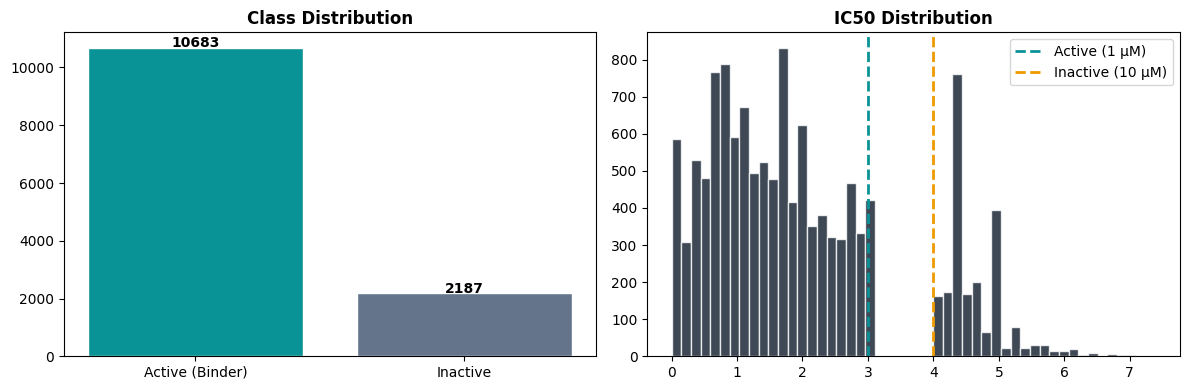

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = processed_df['label'].value_counts()
axes[0].bar(['Active (Binder)','Inactive'],
            [counts.get(1,0), counts.get(0,0)],
            color=['#0A9396','#64748B'], edgecolor='white')
axes[0].set_title('Class Distribution', fontweight='bold')
for i, v in enumerate([counts.get(1,0), counts.get(0,0)]):
    axes[0].text(i, v+10, str(v), ha='center', fontweight='bold')
axes[1].hist(np.log10(processed_df['ic50_parsed']+1), bins=50,
             color='#0D1B2A', edgecolor='white', alpha=0.8)
axes[1].axvline(np.log10(ACTIVE_THRESHOLD_nM),   color='#0A9396',
                ls='--', lw=2, label='Active (1 µM)')
axes[1].axvline(np.log10(INACTIVE_THRESHOLD_nM), color='#EE9B00',
                ls='--', lw=2, label='Inactive (10 µM)')
axes[1].set_title('IC50 Distribution', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig('dataset_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7 — Generate Molecular Images

Generating 12870 images...


100%|██████████| 12870/12870 [02:08<00:00, 100.50it/s]


Done: 12870/12870 images
Dataset size: 12870


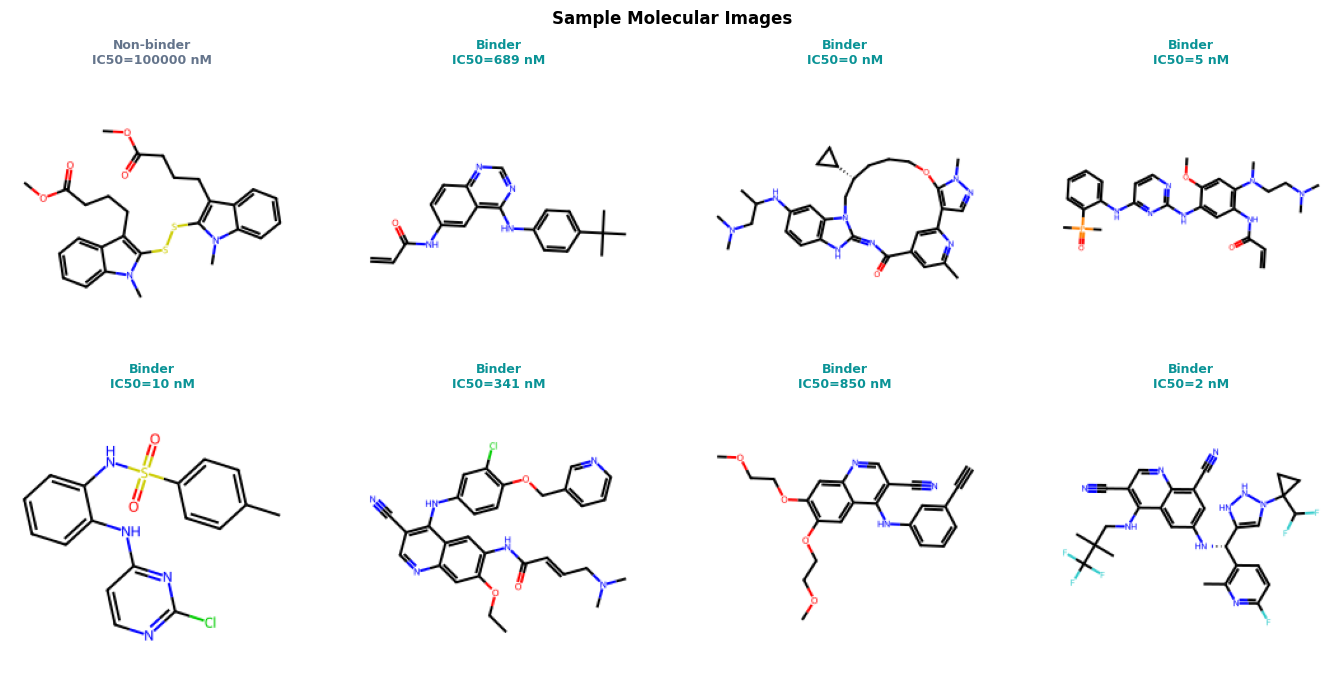

In [ ]:
def smiles_to_image(smiles, img_size=IMG_SIZE):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None: return None
        AllChem.Compute2DCoords(mol)
        return Draw.MolToImage(mol, size=(img_size, img_size)).convert('RGB')
    except Exception:
        return None

def generate_images(df, image_dir=IMAGE_DIR):
    os.makedirs(image_dir, exist_ok=True)
    image_paths, valid_idx = [], []
    print(f"Generating {len(df)} images...")
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        img_path = os.path.join(image_dir, f'mol_{idx}.png')
        if not os.path.exists(img_path):
            img = smiles_to_image(row['canonical_smiles'])
            if img is not None:
                img.save(img_path)
            else:
                continue
        image_paths.append(img_path)
        valid_idx.append(idx)
    result = df.loc[valid_idx].copy()
    result['image_path'] = image_paths
    print(f"Done: {len(result)}/{len(df)} images")
    return result.reset_index(drop=True)

image_df = generate_images(processed_df)
print(f"Dataset size: {len(image_df)}")

# Show samples
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
samples = image_df.sample(min(8, len(image_df)), random_state=SEED)
for ax, (_, row) in zip(axes.flatten(), samples.iterrows()):
    ax.imshow(Image.open(row['image_path']))
    label_str = 'Binder' if row['label']==1 else 'Non-binder'
    ax.set_title(f"{label_str}\nIC50={row['ic50_parsed']:.0f} nM",
                 fontsize=9, color='#0A9396' if row['label']==1 else '#64748B',
                 fontweight='bold')
    ax.axis('off')
plt.suptitle('Sample Molecular Images', fontweight='bold')
plt.tight_layout()
plt.savefig('sample_molecules.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8 — Dataset Split (70/15/15)

In [ ]:
def split_dataset(df):
    train_val, test = train_test_split(
        df, test_size=TEST_RATIO, stratify=df['label'], random_state=SEED)
    val_frac = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
    train, val = train_test_split(
        train_val, test_size=val_frac, stratify=train_val['label'], random_state=SEED)
    print("=== Split Summary ===")
    for name, s in [('Train', train), ('Val', val), ('Test', test)]:
        n, p = len(s), int(s['label'].sum())
        print(f"  {name}: {n} samples | {p} active ({p/n*100:.1f}%) | {n-p} inactive")
    return (train.reset_index(drop=True),
            val.reset_index(drop=True),
            test.reset_index(drop=True))

train_df, val_df, test_df = split_dataset(image_df)

=== Split Summary ===
  Train: 9008 samples | 7477 active (83.0%) | 1531 inactive
  Val: 1931 samples | 1603 active (83.0%) | 328 inactive
  Test: 1931 samples | 1603 active (83.0%) | 328 inactive


## Step 9 — DataLoader

In [ ]:
class MolecularImageDataset(Dataset):
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        if augment:
            self.transform = transforms.Compose([
                transforms.Resize((IMG_SIZE, IMG_SIZE)),
                transforms.RandomHorizontalFlip(),
                transforms.RandomVerticalFlip(),
                transforms.ColorJitter(brightness=0.1, contrast=0.1),
                transforms.ToTensor(),
                transforms.Normalize(self.MEAN, self.STD)
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize((IMG_SIZE, IMG_SIZE)),
                transforms.ToTensor(),
                transforms.Normalize(self.MEAN, self.STD)
            ])

    def __len__(self):  return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        return self.transform(img), torch.tensor(row['label'], dtype=torch.float32)

# Class weight for imbalance
n_pos = int(train_df['label'].sum())
n_neg = len(train_df) - n_pos
pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32).to(DEVICE)
print(f"pos_weight: {pos_weight.item():.4f}  ({n_neg} negatives / {n_pos} positives)")

train_dataset = MolecularImageDataset(train_df, augment=True)
val_dataset   = MolecularImageDataset(val_df,   augment=False)
test_dataset  = MolecularImageDataset(test_df,  augment=False)

# num_workers=0 is safest on Colab
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=(DEVICE.type=='cuda'))
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(DEVICE.type=='cuda'))
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(DEVICE.type=='cuda'))

print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")
print(f"Test  batches: {len(test_loader)}")

# Quick sanity check
imgs, labels = next(iter(train_loader))
print(f"Batch shape: {imgs.shape}  Labels: {labels[:5].tolist()}")
print(f"Image mean: {imgs.mean().item():.4f}  std: {imgs.std().item():.4f}")

pos_weight: 0.2048  (1531 negatives / 7477 positives)
Train batches: 282
Val   batches: 61
Test  batches: 61
Batch shape: torch.Size([32, 3, 224, 224])  Labels: [1.0, 1.0, 1.0, 1.0, 1.0]
Image mean: 2.1903  std: 0.6848


## Step 10 — Build ResNet-18

In [ ]:
def build_resnet18():
    weights = models.ResNet18_Weights.IMAGENET1K_V1
    model   = models.resnet18(weights=weights)
    in_feat = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=DROPOUT_RATE),
        nn.Linear(in_feat, 1)
    )
    return model

model = build_resnet18().to(DEVICE)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"ResNet-18 ready | Total params: {total:,} | Trainable: {trainable:,}")
print(f"Final layer: Dropout({DROPOUT_RATE}) → Linear(512→1)")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 167MB/s]


ResNet-18 ready | Total params: 11,177,025 | Trainable: 11,177,025
Final layer: Dropout(0.3) → Linear(512→1)


## Step 11 — Train ResNet-18

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, all_labels, all_probs = 0.0, [], []
    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.to(device).unsqueeze(1)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        all_probs.extend(torch.sigmoid(logits).detach().cpu().numpy().flatten())
        all_labels.extend(labels.cpu().numpy().flatten())
    avg_loss = total_loss / len(loader.dataset)
    try:    auc = roc_auc_score(all_labels, all_probs)
    except: auc = 0.5
    return avg_loss, auc

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_labels, all_probs = 0.0, [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(device)
            labels = labels.to(device).unsqueeze(1)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)
            all_probs.extend(torch.sigmoid(logits).cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())
    avg_loss = total_loss / len(loader.dataset)
    try:    auc = roc_auc_score(all_labels, all_probs)
    except: auc = 0.5
    return avg_loss, auc, np.array(all_labels), np.array(all_probs)

def train_model(model, train_loader, val_loader):
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

    history = {'train_loss':[], 'val_loss':[], 'train_auc':[], 'val_auc':[]}
    best_val_auc, best_epoch, patience_count = 0.0, 0, 0
    saved = False

    print("=== Training ResNet-18 CNN ===")
    print(f"Device: {DEVICE}  |  Batch: {BATCH_SIZE}  |  LR: {LEARNING_RATE}  |  Patience: {PATIENCE}")
    print(f"Checkpoint: {CHECKPOINT_PATH}")
    print(f"{'Epoch':>6} | {'TrainLoss':>10} | {'ValLoss':>8} | {'TrainAUC':>9} | {'ValAUC':>8} | Status")
    print("-"*65)

    for epoch in range(1, NUM_EPOCHS+1):
        tr_loss, tr_auc          = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        vl_loss, vl_auc, _, _   = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step(vl_auc)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_auc'].append(tr_auc)
        history['val_auc'].append(vl_auc)

        if vl_auc > best_val_auc:
            best_val_auc, best_epoch, patience_count = vl_auc, epoch, 0
            torch.save(model.state_dict(), CHECKPOINT_PATH)
            saved  = True
            status = 'BEST'
        else:
            patience_count += 1
            status = f'{patience_count}/{PATIENCE}'

        print(f"{epoch:>6} | {tr_loss:>10.4f} | {vl_loss:>8.4f} | {tr_auc:>9.4f} | {vl_auc:>8.4f} | {status}")

        if patience_count >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

    if saved:
        model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
        print(f"Best model loaded — epoch {best_epoch}, Val AUC {best_val_auc:.4f}")
    return history

history = train_model(model, train_loader, val_loader)

=== Training ResNet-18 CNN ===
Device: cuda  |  Batch: 32  |  LR: 0.0001  |  Patience: 5
Checkpoint: /content/best_resnet18.pth
 Epoch |  TrainLoss |  ValLoss |  TrainAUC |   ValAUC | Status
-----------------------------------------------------------------
     1 |     0.1475 |   0.1290 |    0.8832 |   0.9168 | BEST
     2 |     0.1146 |   0.1120 |    0.9308 |   0.9384 | BEST
     3 |     0.0971 |   0.1278 |    0.9498 |   0.9357 | 1/5
     4 |     0.0858 |   0.1235 |    0.9605 |   0.9289 | 2/5
     5 |     0.0773 |   0.1178 |    0.9680 |   0.9404 | BEST
     6 |     0.0694 |   0.1179 |    0.9739 |   0.9445 | BEST
     7 |     0.0653 |   0.1269 |    0.9770 |   0.9363 | 1/5
     8 |     0.0592 |   0.1198 |    0.9808 |   0.9327 | 2/5
     9 |     0.0548 |   0.1069 |    0.9835 |   0.9457 | BEST
    10 |     0.0506 |   0.1111 |    0.9853 |   0.9464 | BEST
    11 |     0.0455 |   0.1008 |    0.9882 |   0.9567 | BEST
    12 |     0.0471 |   0.1183 |    0.9872 |   0.9561 | 1/5
    13 |     0.0

## Step 12 — Training Curves

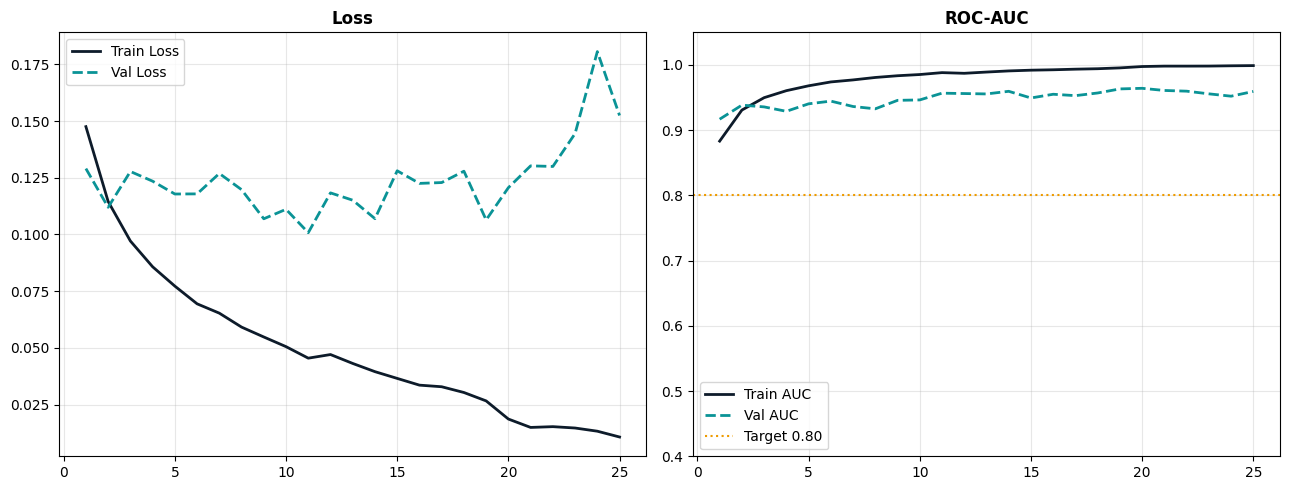

Training curves saved.


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ep = range(1, len(history['train_loss'])+1)
ax1.plot(ep, history['train_loss'], color='#0D1B2A', lw=2, label='Train Loss')
ax1.plot(ep, history['val_loss'],   color='#0A9396', lw=2, ls='--', label='Val Loss')
ax1.set_title('Loss', fontweight='bold'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(ep, history['train_auc'], color='#0D1B2A', lw=2, label='Train AUC')
ax2.plot(ep, history['val_auc'],   color='#0A9396', lw=2, ls='--', label='Val AUC')
ax2.axhline(0.8, color='#EE9B00', ls=':', lw=1.5, label='Target 0.80')
ax2.set_title('ROC-AUC', fontweight='bold'); ax2.set_ylim([0.4,1.05])
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved.")

## Step 13 — Random Forest Baseline

In [ ]:
def smiles_to_morgan(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None: return None
        fp  = AllChem.GetMorganFingerprintAsBitVect(
                  mol, radius=RF_FINGERPRINT_RADIUS, nBits=RF_FINGERPRINT_BITS)
        arr = np.zeros((RF_FINGERPRINT_BITS,), dtype=np.float32)
        DataStructs.ConvertToNumpyArray(fp, arr)
        return arr
    except Exception:
        return None

def make_fp_matrix(df):
    fps, labs = [], []
    for _, row in df.iterrows():
        fp = smiles_to_morgan(row['canonical_smiles'])
        if fp is not None:
            fps.append(fp); labs.append(row['label'])
    return np.array(fps), np.array(labs)

print("=== Random Forest Baseline ===")
X_train, y_train = make_fp_matrix(train_df)
X_test,  y_test  = make_fp_matrix(test_df)
print(f"Fingerprint matrix: {X_train.shape}")

rf = RandomForestClassifier(n_estimators=RF_N_ESTIMATORS,
                             class_weight='balanced',
                             random_state=SEED, n_jobs=-1)
cv = cross_val_score(rf, X_train, y_train,
                     cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                     scoring='roc_auc', n_jobs=-1)
print(f"CV ROC-AUC: {cv.mean():.4f} +/- {cv.std():.4f}")
rf.fit(X_train, y_train)

rf_test_probs  = rf.predict_proba(X_test)[:, 1]
rf_test_labels = y_test
rf_test_preds  = rf.predict(X_test)
rf_metrics = {
    'accuracy':  accuracy_score(y_test, rf_test_preds),
    'precision': precision_score(y_test, rf_test_preds, zero_division=0),
    'recall':    recall_score(y_test, rf_test_preds, zero_division=0),
    'f1':        f1_score(y_test, rf_test_preds, zero_division=0),
    'roc_auc':   roc_auc_score(y_test, rf_test_probs),
    'pr_auc':    average_precision_score(y_test, rf_test_probs)
}
print("RF Test Results:")
for k, v in rf_metrics.items(): print(f"  {k:12s}: {v:.4f}")

=== Random Forest Baseline ===


Streaming output truncated to the last 5000 lines.
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:4

Fingerprint matrix: (9008, 2048)


[15:42:08] DEPRECATION WARNING: please use MorganGenerator
[15:42:08] DEPRECATION WARNING: please use MorganGenerator
[15:42:08] DEPRECATION WARNING: please use MorganGenerator
[15:42:08] DEPRECATION WARNING: please use MorganGenerator
[15:42:08] DEPRECATION WARNING: please use MorganGenerator
[15:42:08] DEPRECATION WARNING: please use MorganGenerator
[15:42:08] DEPRECATION WARNING: please use MorganGenerator
[15:42:08] DEPRECATION WARNING: please use MorganGenerator
[15:42:08] DEPRECATION WARNING: please use MorganGenerator
[15:42:08] DEPRECATION WARNING: please use MorganGenerator
[15:42:08] DEPRECATION WARNING: please use MorganGenerator
[15:42:08] DEPRECATION WARNING: please use MorganGenerator
[15:42:08] DEPRECATION WARNING: please use MorganGenerator
[15:42:08] DEPRECATION WARNING: please use MorganGenerator
[15:42:08] DEPRECATION WARNING: please use MorganGenerator
[15:42:08] DEPRECATION WARNING: please use MorganGenerator
[15:42:08] DEPRECATION WARNING: please use MorganGenerat

CV ROC-AUC: 0.9803 +/- 0.0043
RF Test Results:
  accuracy    : 0.9591
  precision   : 0.9692
  recall      : 0.9819
  f1          : 0.9755
  roc_auc     : 0.9865
  pr_auc      : 0.9970


## Step 14 — CNN Evaluation

In [ ]:
model.eval()
all_labels, all_probs = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs   = imgs.to(DEVICE)
        logits = model(imgs)
        probs  = torch.sigmoid(logits).cpu().numpy().flatten()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

cnn_test_labels = np.array(all_labels)
cnn_test_probs  = np.array(all_probs)
cnn_test_preds  = (cnn_test_probs >= 0.5).astype(int)

cnn_metrics = {
    'accuracy':  accuracy_score(cnn_test_labels, cnn_test_preds),
    'precision': precision_score(cnn_test_labels, cnn_test_preds, zero_division=0),
    'recall':    recall_score(cnn_test_labels, cnn_test_preds, zero_division=0),
    'f1':        f1_score(cnn_test_labels, cnn_test_preds, zero_division=0),
    'roc_auc':   roc_auc_score(cnn_test_labels, cnn_test_probs),
    'pr_auc':    average_precision_score(cnn_test_labels, cnn_test_probs)
}
print("=== CNN Test Results ===")
for k, v in cnn_metrics.items(): print(f"  {k:12s}: {v:.4f}")

=== CNN Test Results ===
  accuracy    : 0.9208
  precision   : 0.9647
  recall      : 0.9389
  f1          : 0.9516
  roc_auc     : 0.9573
  pr_auc      : 0.9900


## Step 15 — Model Comparison

  RESULTS: ResNet-18 CNN vs Random Forest
Metric                    CNN             RF     Delta
-------------------------------------------------------
Accuracy               0.9208         0.9591  ↓ -0.0383
Precision              0.9647         0.9692  ↓ -0.0045
Recall                 0.9389         0.9819  ↓ -0.0430
F1-Score               0.9516         0.9755  ↓ -0.0239
ROC-AUC                0.9573         0.9865  ↓ -0.0292
PR-AUC                 0.9900         0.9970  ↓ -0.0071


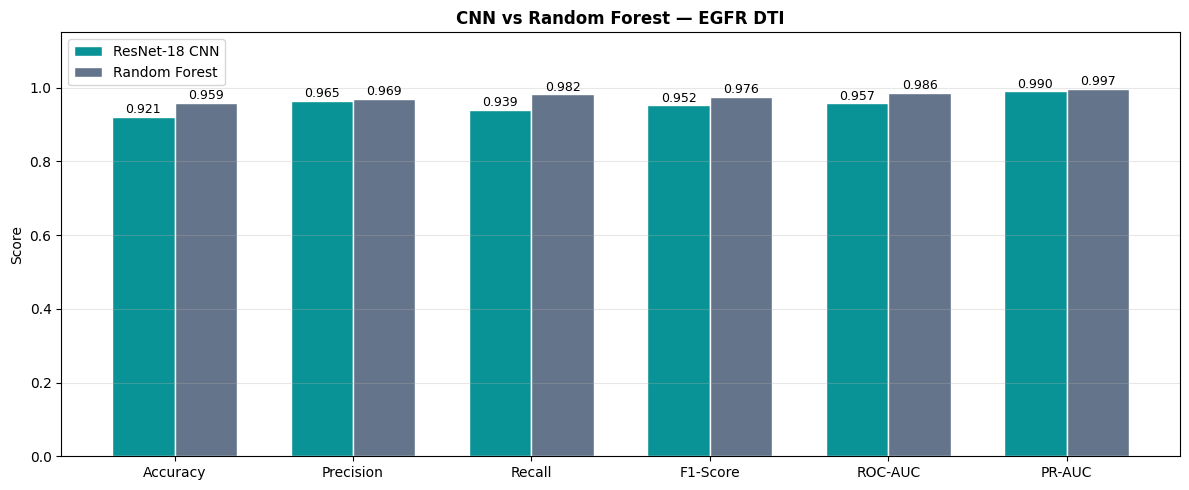

In [ ]:
metric_names  = ['accuracy','precision','recall','f1','roc_auc','pr_auc']
display_names = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC','PR-AUC']

print("="*60)
print("  RESULTS: ResNet-18 CNN vs Random Forest")
print("="*60)
print(f"{'Metric':<15} {'CNN':>13} {'RF':>14}  {'Delta':>8}")
print("-"*55)
for m, d in zip(metric_names, display_names):
    cv = cnn_metrics[m]; rv = rf_metrics[m]; delta = cv - rv
    print(f"{d:<15} {cv:>13.4f} {rv:>14.4f}  {'↑' if delta>0 else '↓'} {delta:>+.4f}")
print("="*60)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(display_names)); w = 0.35
b1 = ax.bar(x-w/2, [cnn_metrics[m] for m in metric_names], w,
            label='ResNet-18 CNN', color='#0A9396', edgecolor='white')
b2 = ax.bar(x+w/2, [rf_metrics[m]  for m in metric_names], w,
            label='Random Forest', color='#64748B', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(display_names)
ax.set_ylim([0, 1.15]); ax.set_ylabel('Score')
ax.set_title('CNN vs Random Forest — EGFR DTI', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 16 — ROC & PR Curves

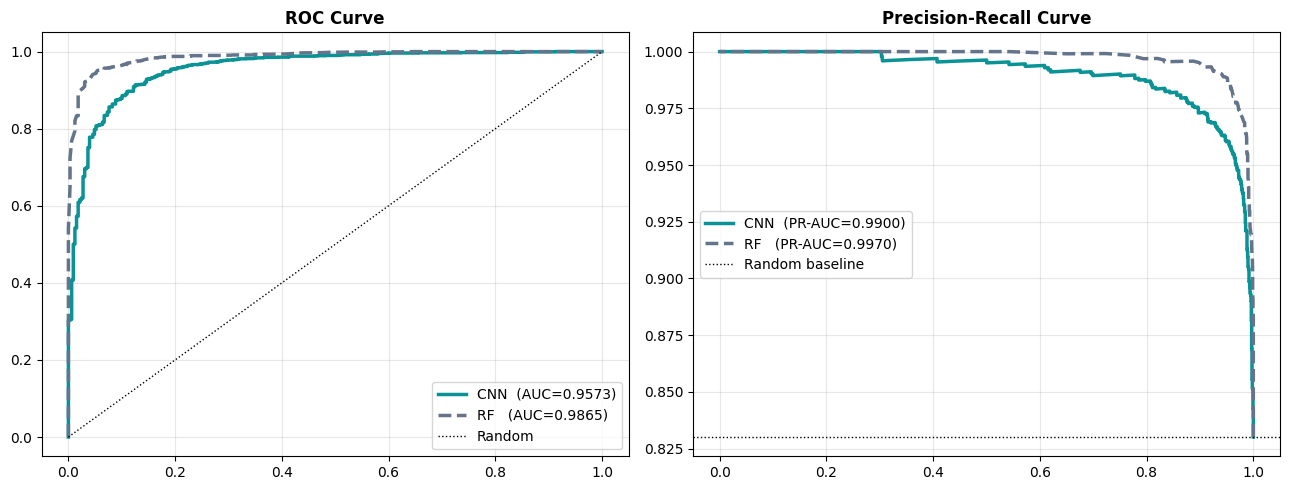

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fpr_c,tpr_c,_ = roc_curve(cnn_test_labels, cnn_test_probs)
fpr_r,tpr_r,_ = roc_curve(rf_test_labels,  rf_test_probs)
ax1.plot(fpr_c, tpr_c, color='#0A9396', lw=2.5, label=f'CNN  (AUC={cnn_metrics["roc_auc"]:.4f})')
ax1.plot(fpr_r, tpr_r, color='#64748B', lw=2.5, ls='--', label=f'RF   (AUC={rf_metrics["roc_auc"]:.4f})')
ax1.plot([0,1],[0,1],'k:',lw=1,label='Random')
ax1.set_title('ROC Curve', fontweight='bold'); ax1.legend(); ax1.grid(alpha=0.3)

pr_c,rc_c,_ = precision_recall_curve(cnn_test_labels, cnn_test_probs)
pr_r,rc_r,_ = precision_recall_curve(rf_test_labels,  rf_test_probs)
ax2.plot(rc_c, pr_c, color='#0A9396', lw=2.5, label=f'CNN  (PR-AUC={cnn_metrics["pr_auc"]:.4f})')
ax2.plot(rc_r, pr_r, color='#64748B', lw=2.5, ls='--', label=f'RF   (PR-AUC={rf_metrics["pr_auc"]:.4f})')
ax2.axhline(cnn_test_labels.mean(), color='k', ls=':', lw=1, label='Random baseline')
ax2.set_title('Precision-Recall Curve', fontweight='bold'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 17 — Confusion Matrices

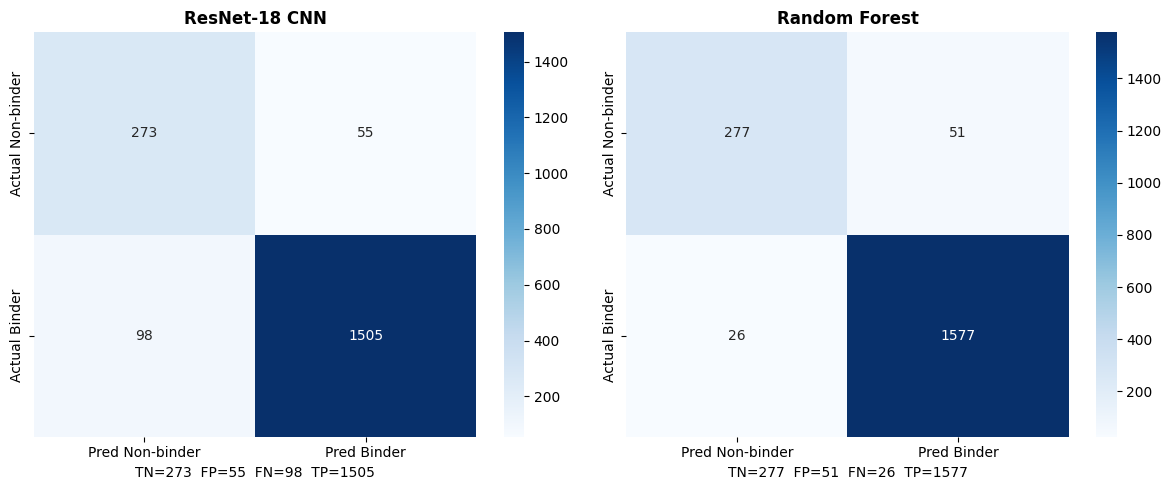

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
def plot_cm(ax, labels, probs, title):
    preds = (probs>=0.5).astype(int)
    cm    = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Non-binder','Pred Binder'],
                yticklabels=['Actual Non-binder','Actual Binder'])
    ax.set_title(title, fontweight='bold')
    tn,fp,fn,tp = cm.ravel()
    ax.set_xlabel(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')
plot_cm(ax1, cnn_test_labels, cnn_test_probs, 'ResNet-18 CNN')
plot_cm(ax2, rf_test_labels,  rf_test_probs,  'Random Forest')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 18 — Error Analysis

=== ResNet-18 CNN ===
  TP: 1505  TN: 273
  FP: 55  FN: 98


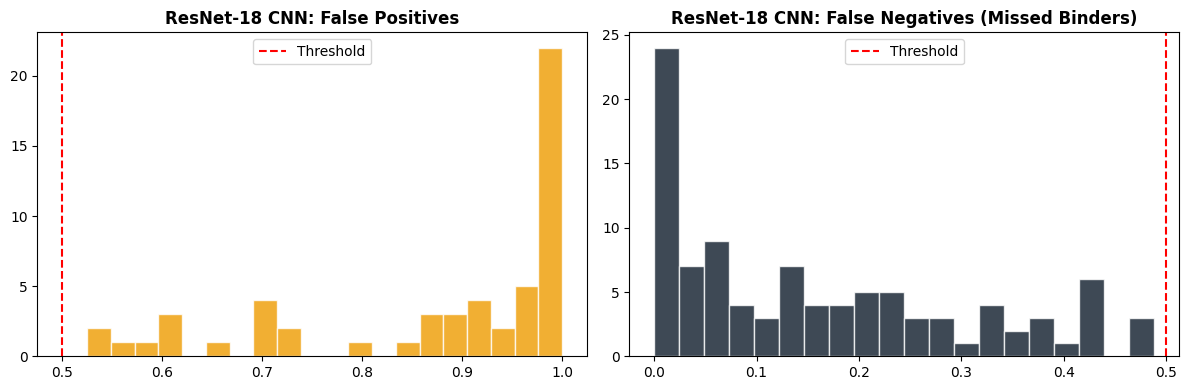

=== Random Forest ===
  TP: 1577  TN: 277
  FP: 51  FN: 26


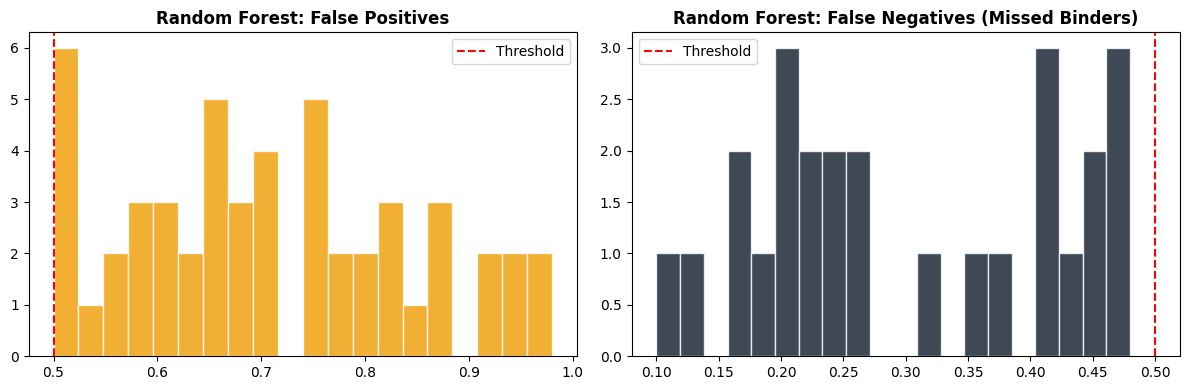

In [ ]:
def error_analysis(probs, labels, model_name):
    preds   = (probs>=0.5).astype(int)
    fp_mask = (preds==1)&(labels==0)
    fn_mask = (preds==0)&(labels==1)
    print(f"=== {model_name} ===")
    print(f"  TP: {int(((preds==1)&(labels==1)).sum())}  TN: {int(((preds==0)&(labels==0)).sum())}")
    print(f"  FP: {int(fp_mask.sum())}  FN: {int(fn_mask.sum())}")
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(probs[fp_mask], bins=20, color='#EE9B00', edgecolor='white', alpha=0.8)
    axes[0].set_title(f'{model_name}: False Positives', fontweight='bold')
    axes[0].axvline(0.5, color='red', ls='--', label='Threshold'); axes[0].legend()
    axes[1].hist(probs[fn_mask], bins=20, color='#0D1B2A', edgecolor='white', alpha=0.8)
    axes[1].set_title(f'{model_name}: False Negatives (Missed Binders)', fontweight='bold')
    axes[1].axvline(0.5, color='red', ls='--', label='Threshold'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f'error_{model_name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

error_analysis(cnn_test_probs, cnn_test_labels, 'ResNet-18 CNN')
error_analysis(rf_test_probs,  rf_test_labels,  'Random Forest')

## Step 19 — Grad-CAM Interpretability
Highlights which regions of the molecular image the CNN focuses on.  
**Red/Yellow = high attention | Blue = low attention**

Grad-CAM ready.


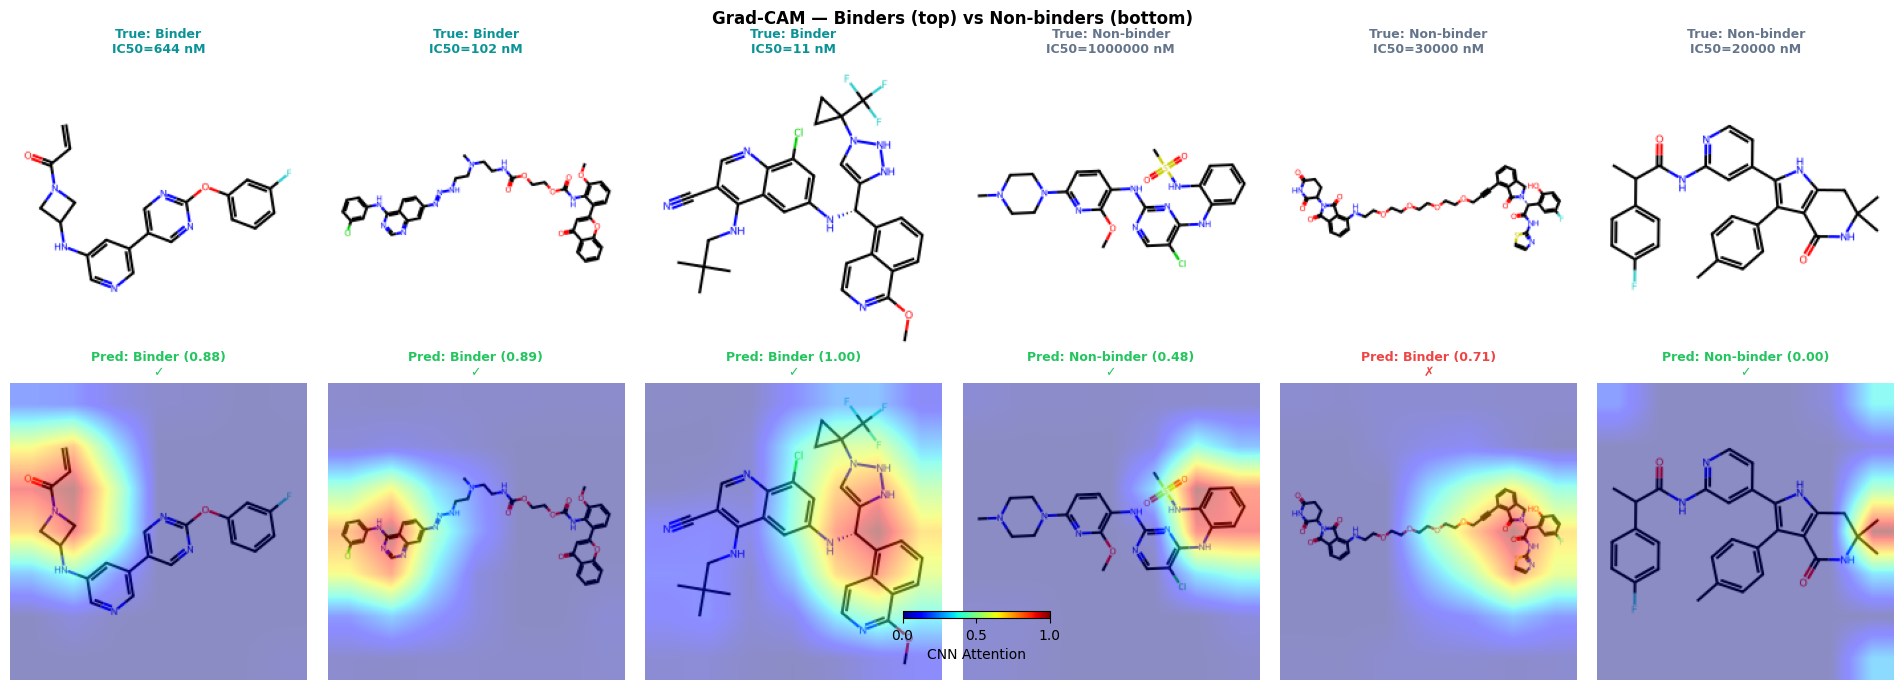

Saved: gradcam_analysis.png


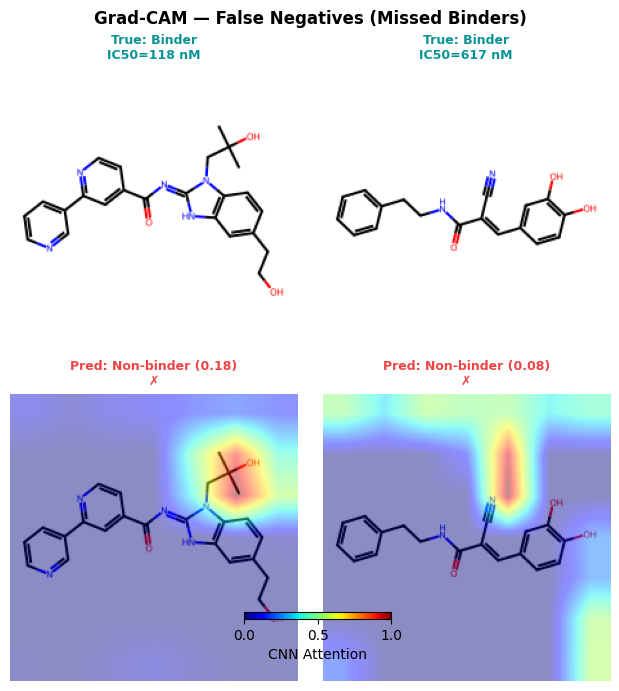

Saved: gradcam_analysis.png
Grad-CAM done.


In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        self.fwd = target_layer.register_forward_hook(self._fwd_hook)
        self.bwd = target_layer.register_full_backward_hook(self._bwd_hook)

    def _fwd_hook(self, m, i, o): self.activations = o.detach()
    def _bwd_hook(self, m, gi, go): self.gradients  = go[0].detach()

    def generate(self, tensor):
        self.model.eval()
        inp    = tensor.to(DEVICE).requires_grad_(True)
        out    = self.model(inp)
        prob   = torch.sigmoid(out).item()
        self.model.zero_grad()
        out.backward()
        weights = self.gradients.mean(dim=[2,3], keepdim=True)
        cam     = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam     = F.interpolate(cam, size=(224,224), mode='bilinear', align_corners=False)
        cam     = cam.squeeze().cpu().numpy()
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        return cam, prob

    def remove(self): self.fwd.remove(); self.bwd.remove()

def overlay(img_path, cam, alpha=0.45):
    orig = np.array(Image.open(img_path).convert('RGB').resize((224,224)))
    heat = (mpl_cm.jet(cam)[:,:,:3] * 255).astype(np.uint8)
    return (orig*(1-alpha) + heat*alpha).astype(np.uint8)

infer_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

gradcam = GradCAM(model, model.layer4[-1])
print("Grad-CAM ready.")

# Select samples
binders    = test_df[test_df['label']==1].sample(3, random_state=SEED)
nonbinders = test_df[test_df['label']==0].sample(3, random_state=SEED)
fn_mask    = ((cnn_test_probs<0.5).astype(int)==1) & (cnn_test_labels==1)
fn_df      = test_df.iloc[np.where(fn_mask)[0][:2]].copy()

def gradcam_grid(samples_df, title):
    n   = len(samples_df)
    fig, axes = plt.subplots(2, n, figsize=(n*3.2, 7))
    if n == 1: axes = axes.reshape(2,1)
    fig.suptitle(title, fontsize=12, fontweight='bold')
    for col, (_, row) in enumerate(samples_df.iterrows()):
        pil  = Image.open(row['image_path']).convert('RGB')
        cam, prob = gradcam.generate(infer_tf(pil).unsqueeze(0))
        over = overlay(row['image_path'], cam)
        true = 'Binder' if row['label']==1 else 'Non-binder'
        pred = 'Binder' if prob>=0.5 else 'Non-binder'
        ok   = (row['label']==1)==(prob>=0.5)
        axes[0,col].imshow(np.array(pil.resize((224,224))))
        axes[0,col].set_title(f"True: {true}\nIC50={row['ic50_parsed']:.0f} nM",
                               fontsize=9, fontweight='bold',
                               color='#0A9396' if row['label']==1 else '#64748B')
        axes[0,col].axis('off')
        axes[1,col].imshow(over)
        axes[1,col].set_title(f"Pred: {pred} ({prob:.2f})\n{'✓' if ok else '✗'}",
                               fontsize=9, fontweight='bold',
                               color='#22C55E' if ok else '#EF4444')
        axes[1,col].axis('off')
    axes[0,0].set_ylabel("Original",  fontsize=11, fontweight='bold')
    axes[1,0].set_ylabel("Grad-CAM",  fontsize=11, fontweight='bold')
    sm = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(0,1)); sm.set_array([])
    plt.colorbar(sm, ax=axes[1,:], orientation='horizontal',
                 fraction=0.03, pad=0.08, shrink=0.6).set_label('CNN Attention')
    plt.tight_layout()
    plt.savefig('gradcam_analysis.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("Saved: gradcam_analysis.png")

gradcam_grid(pd.concat([binders, nonbinders]).reset_index(drop=True),
             "Grad-CAM — Binders (top) vs Non-binders (bottom)")
if len(fn_df) > 0:
    gradcam_grid(fn_df.reset_index(drop=True),
                 "Grad-CAM — False Negatives (Missed Binders)")
gradcam.remove()
print("Grad-CAM done.")

## Step 20 — Save All Results

In [ ]:
# Metrics CSV
pd.DataFrame({
    'Metric':       display_names,
    'ResNet18_CNN': [cnn_metrics[m] for m in metric_names],
    'RandomForest': [rf_metrics[m]  for m in metric_names]
}).to_csv('final_results.csv', index=False)
print("Saved: final_results.csv")

# CNN weights
torch.save(model.state_dict(), '/content/resnet18_egfr_final.pth')
print("Saved: resnet18_egfr_final.pth")

# Random Forest
with open('/content/random_forest_egfr.pkl','wb') as f:
    pickle.dump(rf, f)
print("Saved: random_forest_egfr.pkl")

# Final summary
print("\n" + "="*60)
print("  FINAL RESULTS — EGFR DTI | CS697-AI687-001 | Group 3")
print("="*60)
print(f"{'Metric':<15} {'CNN':>13} {'RF':>14}  {'Delta':>8}")
print("-"*55)
for m, d in zip(metric_names, display_names):
    cv=cnn_metrics[m]; rv=rf_metrics[m]; delta=cv-rv
    print(f"{d:<15} {cv:>13.4f} {rv:>14.4f}  {'↑' if delta>0 else '↓'} {delta:>+.4f}")
print("="*60)

# File check
print("\nOutput files:")
for f in ['final_results.csv','training_curves.png','model_comparison.png',
          'roc_pr_curves.png','confusion_matrices.png','gradcam_analysis.png',
          '/content/resnet18_egfr_final.pth','/content/random_forest_egfr.pkl']:
    print(f"  [{'OK' if os.path.exists(f) else 'MISSING'}]  {f}")

Saved: final_results.csv
Saved: resnet18_egfr_final.pth
Saved: random_forest_egfr.pkl

  FINAL RESULTS — EGFR DTI | CS697-AI687-001 | Group 3
Metric                    CNN             RF     Delta
-------------------------------------------------------
Accuracy               0.9208         0.9591  ↓ -0.0383
Precision              0.9647         0.9692  ↓ -0.0045
Recall                 0.9389         0.9819  ↓ -0.0430
F1-Score               0.9516         0.9755  ↓ -0.0239
ROC-AUC                0.9573         0.9865  ↓ -0.0292
PR-AUC                 0.9900         0.9970  ↓ -0.0071

Output files:
  [OK]  final_results.csv
  [OK]  training_curves.png
  [OK]  model_comparison.png
  [OK]  roc_pr_curves.png
  [OK]  confusion_matrices.png
  [OK]  gradcam_analysis.png
  [OK]  /content/resnet18_egfr_final.pth
  [OK]  /content/random_forest_egfr.pkl
